Add you import statements in the below code block. Please make sure to import Precode.

In [7]:
# import code here
from precode import *
import numpy
import pandas as pd

data = np.load('AllSamples.npy')

Below cell contains starter code to generate the initial centers. 

* Please do not change anything apart from the student ID.

* The initial centers will be in a dictionary with keys being 'k' and value being the centers.


In [8]:
initial_centers = {}
for k in range(2, 11):
    centers = initial_S1("2599", k)  # please replace 0111 with your last four digit of your ID
    initial_centers[k] = centers

Print the last 4 digits of your student id as string in the cell below. Please make sure to only have one print statement in the cell below.

In [9]:
### TEST FUNCTION: test_student_id
# DO NOT REMOVE THE ABOVE LINE
print("2599")

2599


Add your code for computing the kMeans final centroids and loss functions in the code block below.

In [12]:
def kmeans(data, initial_centers, max_iter=1000):
    centers = np.array(initial_centers, dtype=float)
    k = len(centers)
    
    for _ in range(max_iter):
        # Assign each point to nearest centroid
        distances = np.linalg.norm(data[:, np.newaxis] - centers, axis=2)
        labels = np.argmin(distances, axis=1)
        
        # Recompute centroids
        new_centers = np.array([
            data[labels == i].mean(axis=0) if np.any(labels == i) else centers[i]
            for i in range(k)
        ])
        
        # Check convergence
        if np.allclose(centers, new_centers):
            break
        centers = new_centers
    
    # Compute loss (objective function)
    loss = sum(
        np.sum(np.linalg.norm(data[labels == i] - centers[i], axis=1) ** 2)
        for i in range(k)
    )
    
    return centers, labels, loss


# Run K-Means for k = 2 to 10
results = {}
for k in range(2, 11):
    centers, labels, loss = kmeans(data, initial_centers[k])
    results[k] = {'centers': centers, 'labels': labels, 'loss': loss}

Please use the following cell to print all the final centeriods for k in the range of 2 to 10, both inclusive.

**Notes:**
* The centeriods should have the following format: `[[x1,y1],[x2,y2],[x3,y3]][[x1,y1],[x2,y2],[x3,y3]]`
* The order of the centeriod does not matter but do NOT change the order for `x` and `y` coordinate.
* Please print the centroids from k=2 to k=10 in order and each on a new line.
* Do not print anything else in the code cell below.

**Output format:**

[[x1, y1], [x2, y2]]

[[x1, y1], [x2, y2], [x3, y3]]

.

.

.

[[x1,y1], [x2,y2].....[x9,y9]]

In [13]:
### TEST FUNCTION: test_question1
# DO NOT REMOVE THE ABOVE LINE
for k in range(2, 11):
    centers = results[k]['centers']
    print([[float(x), float(y)] for x, y in centers])

[[4.852611930287174, 7.271641711202775], [5.000562341588762, 2.4854274751531933]]
[[5.477400388679034, 2.254981027984723], [2.5614644894663545, 6.088613382895479], [6.497249620849709, 7.522972929895171]]
[[7.252626831256577, 2.4001582635520533], [2.8337661044723124, 6.918956898933875], [3.2428534716041297, 2.551979054939448], [6.579576431887845, 7.57333594820388]]
[[2.8749081274874264, 7.010822811156844], [2.681986334188929, 2.094615867800809], [6.7786424038212285, 8.079676411164815], [5.223212739403405, 4.2250282852390075], [7.556167822397726, 2.235167959857534]]
[[5.309444507053358, 7.451442698679931], [2.541652523310345, 7.002678323536489], [2.681986334188929, 2.094615867800809], [7.914309977818314, 8.519909807700076], [7.556167822397726, 2.235167959857534], [5.171841785983008, 4.219153691595018]]
[[7.986758244802879, 3.012729309091755], [6.078733050391577, 5.869936972601599], [3.1757786997757065, 7.156076116526353], [4.818330576085663, 3.69502320071854], [7.528740374493046, 8.55574

Please use the following cell to print all the final loss functions for k in the range of 2 to 10, both inclusive.

**Notes:**

* Print the loss functions for every value of k on a new line and in order.
* Do not print anything else in the code cell below.

**Output format:**

L1

L2

.

.

.

L9


In [14]:
### TEST FUNCTION: test_question2
# DO NOT REMOVE THE ABOVE LINE
for k in range(2, 11):
    print(results[k]['loss'])

1921.033485856206
1293.777452391135
788.9645806635215
598.5546443663115
463.21368616569055
454.94852393739626
317.4352805613343
258.49471000686447
182.8592964135696


**This part of the project is manually graded.**

Use the cells below to write the code for generating the loss function plot.

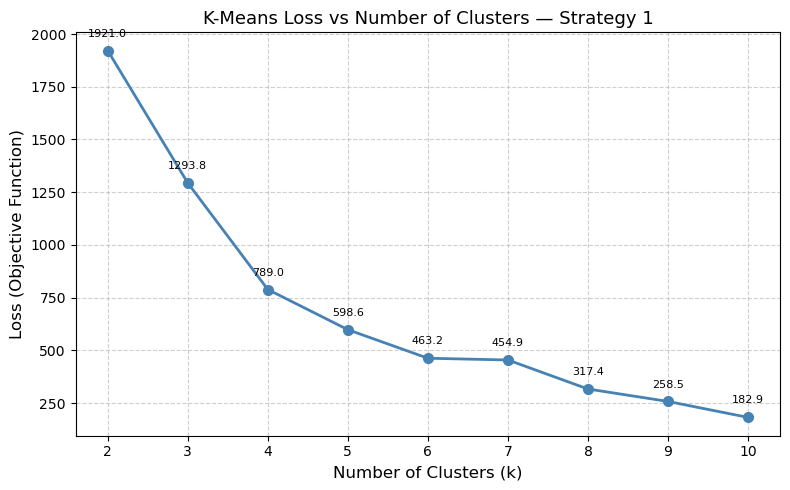

In [18]:
import matplotlib.pyplot as plt

losses = [results[k]['loss'] for k in range(2, 11)]

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), losses, marker='o', color='steelblue', linewidth=2, markersize=7)

for k, loss in zip(range(2, 11), losses):
    plt.annotate(f'{loss:.1f}', (k, loss), textcoords="offset points",
                 xytext=(0, 10), ha='center', fontsize=8)

plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Loss (Objective Function)', fontsize=12)
plt.title('K-Means Loss vs Number of Clusters — Strategy 1', fontsize=13)
plt.xticks(range(2, 11))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('loss_vs_k_s1.png', dpi=150)
plt.show()

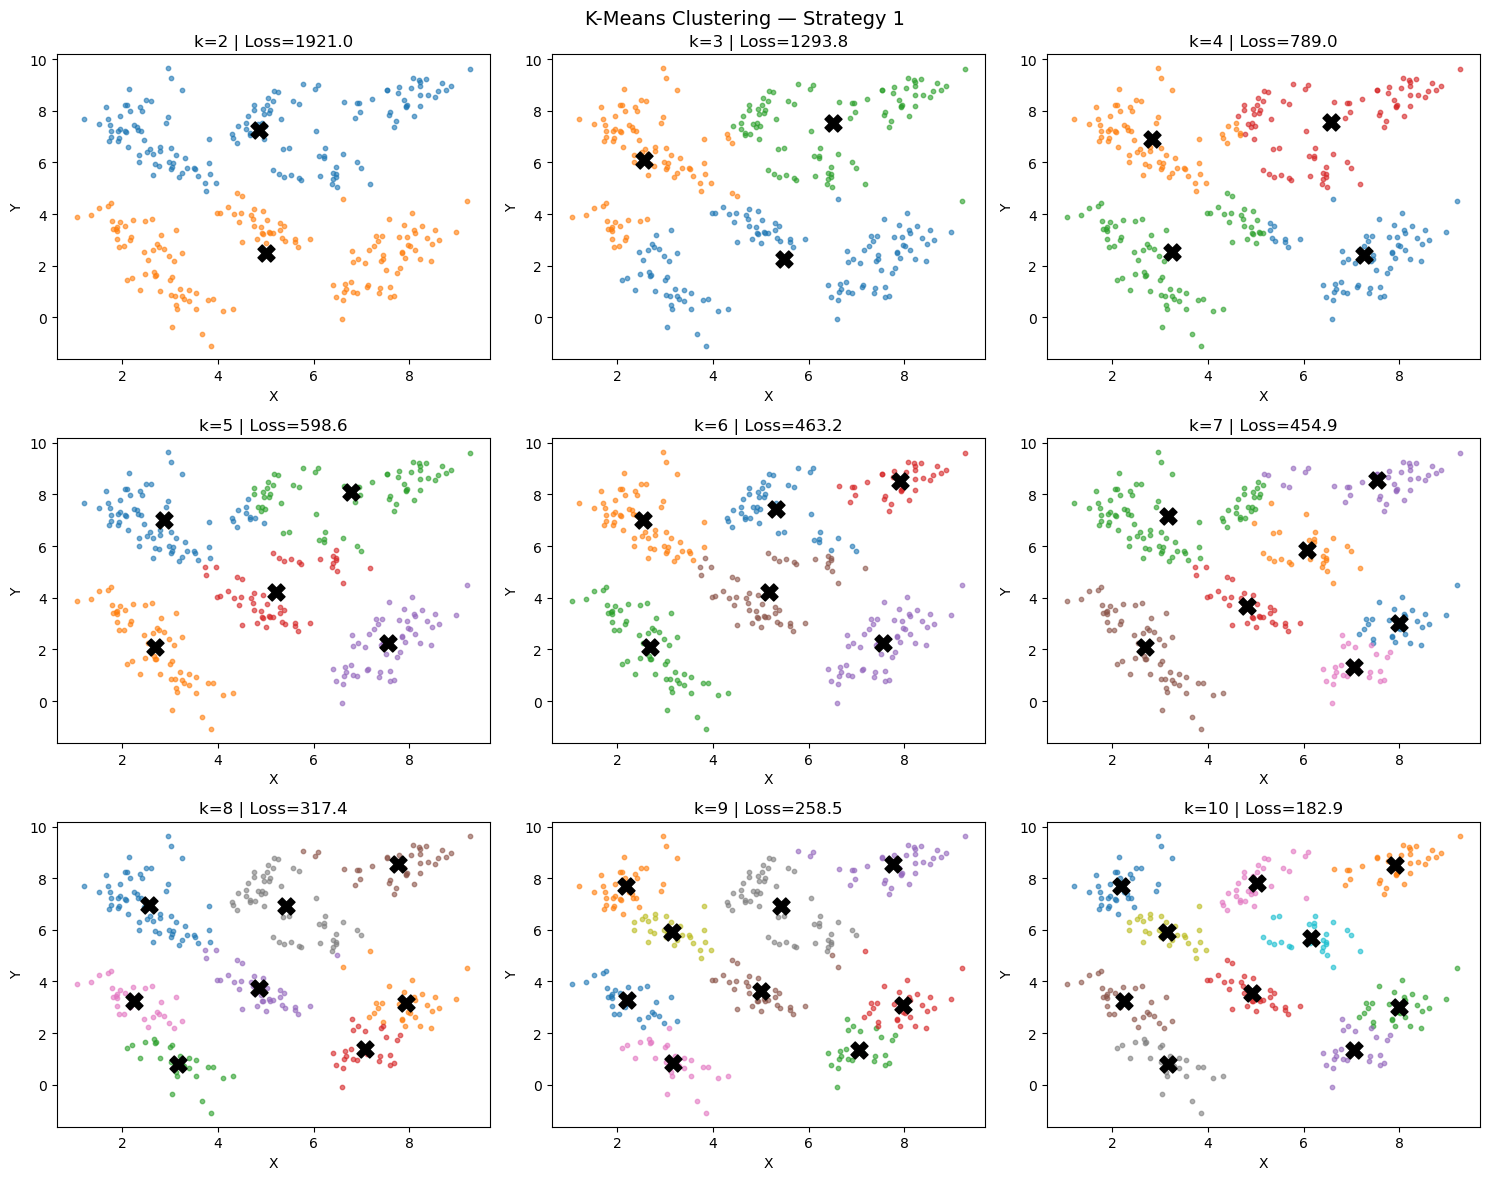

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
colors = plt.cm.tab10.colors

for idx, k in enumerate(range(2, 11)):
    ax = axes[idx // 3][idx % 3]
    centers = results[k]['centers']
    labels  = results[k]['labels']

    for i in range(k):
        pts = data[labels == i]
        ax.scatter(pts[:, 0], pts[:, 1], color=colors[i % 10], s=10, alpha=0.6)
        ax.scatter(centers[i, 0], centers[i, 1],
                   color='black', marker='X', s=150, zorder=5)

    ax.set_title(f'k={k} | Loss={results[k]["loss"]:.1f}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

plt.suptitle('K-Means Clustering — Strategy 1', fontsize=14)
plt.tight_layout()
plt.savefig('clustering_s1.png', dpi=150, bbox_inches='tight')
plt.show()